In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json, warnings, torch, math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List
warnings.filterwarnings("ignore")

from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          Trainer, TrainingArguments, DataCollatorForLanguageModeling,
                          TrainerCallback, EarlyStoppingCallback, BitsAndBytesConfig)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from datasets import load_from_disk

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.cuda.empty_cache()

In [2]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
MODEL_TAG = "qwen25"
DATASET = "finance"

print(f"CUDA: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET}")

@dataclass
class FTConfig:
    target_modules: List[str] = None
    r: int = 16
    alpha: int = 32
    dropout: float = 0.05
    lr: float = 2e-4
    weight_decay: float = 0.01
    warmup_steps: int = 50
    batch_size: int = 2
    grad_accum: int = 2
    num_epochs: int = 1
    max_length: int = 512
    max_grad_norm: float = 1.0
    early_stopping_patience: int = 3
    def __post_init__(self):
        if self.target_modules is None:
            self.target_modules = ["q_proj", "v_proj"]

CFG = FTConfig()
print(f"Model: {MODEL_NAME}")
print(f"Effective batch: {CFG.batch_size * CFG.grad_accum}")
print(f"Epochs: {CFG.num_epochs}, LR: {CFG.lr}, Warmup: {CFG.warmup_steps} steps")

CUDA: NVIDIA GeForce RTX 5080 Laptop GPU
VRAM: 17.1 GB
Model: Qwen/Qwen2.5-3B-Instruct
Dataset: finance
Model: Qwen/Qwen2.5-3B-Instruct
Effective batch: 4
Epochs: 1, LR: 0.0002, Warmup: 50 steps


In [3]:
class CatastrophicForgettingCallback(TrainerCallback):
    def __init__(self):
        self.eval_losses = []
        self.signals = []
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_loss" in metrics:
            loss = metrics["eval_loss"]
            if self.eval_losses and loss > self.eval_losses[-1] * 1.2:
                self.signals.append({"step": state.global_step,
                                     "loss": loss, "prev": self.eval_losses[-1]})
            self.eval_losses.append(loss)

class ContinuousGPUCallback(TrainerCallback):
    """Monitor GPU utilization without causing CUDA sync stalls"""
    def __init__(self):
        self.gpu_utilization_issues = []
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "train_loss" in logs:
            gpu_memory = torch.cuda.memory_allocated() / 1024**3
            logs["gpu_memory_gb"] = gpu_memory
            if state.global_step % 50 == 0:
                print(f"Step {state.global_step}: Loss={logs['train_loss']:.4f}, GPU={gpu_memory:.1f}GB")

In [4]:
# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
print("4-bit NF4 quantization config ready")

4-bit NF4 quantization config ready


In [5]:
def load_and_prepare_model(cfg=CFG):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, 
        quantization_config=bnb_config, 
        device_map="auto",
        trust_remote_code=True
    )
    
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)
    model.gradient_checkpointing_disable()

    peft_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM, 
        r=cfg.r, 
        lora_alpha=cfg.alpha,
        lora_dropout=cfg.dropout, 
        target_modules=cfg.target_modules,
        bias="none", 
        inference_mode=False
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()
    return model, tokenizer

def load_and_tokenize(dataset_name, tokenizer, cfg=CFG):
    data_dir = f"data/{dataset_name}"
    train_ds = load_from_disk(f"{data_dir}/train")
    try:
        val_ds = load_from_disk(f"{data_dir}/validation")
        if len(val_ds) == 0: raise ValueError("empty")
    except Exception:
        n = min(max(len(train_ds) // 10, 50), 500)
        val_ds = train_ds.select(range(n))

    def tok(examples):
        texts = []
        for i in range(len(examples["instruction"])):
            t = f"### Instruction:\n{examples['instruction'][i]}\n\n"
            if examples["input"][i]:
                t += f"### Input:\n{examples['input'][i]}\n\n"
            t += f"### Response:\n{examples['output'][i]}"
            texts.append(t)
        return tokenizer(texts, truncation=True, max_length=cfg.max_length, padding="max_length")

    tok_train = train_ds.map(tok, batched=True, remove_columns=train_ds.column_names, batch_size=1000)
    tok_val = val_ds.map(tok, batched=True, remove_columns=val_ds.column_names, batch_size=1000)

    tok_train.set_format("torch")
    tok_val.set_format("torch")

    print(f"  Tokenized: train={len(tok_train):,}, val={len(tok_val):,} (format=torch)")
    return tok_train, tok_val

In [6]:
def train_model_setup(dataset_name, cfg=CFG):
    out_dir = f"finetuned_models_{MODEL_TAG}/{dataset_name}"
    os.makedirs(out_dir, exist_ok=True)
    return out_dir

def create_callbacks():
    cf_cb = CatastrophicForgettingCallback()
    gpu_cb = ContinuousGPUCallback()
    return cf_cb, gpu_cb

def create_training_args(out_dir, cfg=CFG):
    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=cfg.num_epochs,
        per_device_train_batch_size=cfg.batch_size,
        per_device_eval_batch_size=cfg.batch_size,
        gradient_accumulation_steps=cfg.grad_accum,
        learning_rate=cfg.lr, 
        weight_decay=cfg.weight_decay,
        warmup_steps=cfg.warmup_steps, 
        lr_scheduler_type="cosine",
        max_grad_norm=cfg.max_grad_norm,
        eval_strategy="steps",
        eval_steps=250,
        save_strategy="steps",
        save_steps=500,
        save_total_limit=2,
        eval_accumulation_steps=4,
        load_best_model_at_end=True, 
        metric_for_best_model="eval_loss",
        greater_is_better=False, 
        logging_steps=25,
        logging_first_step=True,
        bf16=True, 
        tf32=True, 
        seed=42, 
        report_to="none",
        dataloader_pin_memory=True, 
        dataloader_num_workers=4,
        dataloader_prefetch_factor=4,
        dataloader_persistent_workers=True,
        dataloader_drop_last=True,
        torch_empty_cache_steps=100,
        gradient_checkpointing=False,
        optim="adamw_torch_fused",
        adam_beta1=0.9,
        adam_beta2=0.95,
    )
    return args

In [7]:
def create_trainer(model, tokenizer, tok_train, tok_val, args, cf_cb, gpu_cb, cfg=CFG):
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        data_collator=collator,
        callbacks=[cf_cb, gpu_cb, EarlyStoppingCallback(early_stopping_patience=cfg.early_stopping_patience)]
    )
    return trainer

In [8]:
def run_training_and_save(trainer, tokenizer, out_dir, dataset_name, cf_cb, gpu_cb, cfg=CFG):
    print(f"Starting training on {dataset_name} dataset...")
    print(f"Expected steps per epoch: {len(trainer.train_dataset) // (cfg.batch_size * cfg.grad_accum)}")

    result = trainer.train()

    # Report GPU utilization issues
    if gpu_cb.gpu_utilization_issues:
        print(f"GPU utilization issues detected: {len(gpu_cb.gpu_utilization_issues)}")
        for issue in gpu_cb.gpu_utilization_issues[:5]:
            print(f"  Step {issue['step']}: {issue['issue']} ({issue['memory_gb']:.1f}GB)")

    model_path = f"{out_dir}/final_model"
    trainer.save_model(model_path)
    tokenizer.save_pretrained(model_path)

    return result, model_path

In [9]:
def create_training_summary(dataset_name, result, model_path, cf_cb, gpu_cb, cfg=CFG):
    summary = {
        "dataset": dataset_name,
        "model": MODEL_NAME,
        "tag": MODEL_TAG,
        "model_path": model_path,
        "train_loss": result.training_loss,
        "forgetting_signals": cf_cb.signals,
        "eval_losses": cf_cb.eval_losses,
        "gpu_utilization_issues": gpu_cb.gpu_utilization_issues,
        "effective_batch_size": cfg.batch_size * cfg.grad_accum
    }

    out_dir = f"finetuned_models_{MODEL_TAG}/{dataset_name}"
    json.dump(summary, open(f"{out_dir}/training_summary.json", "w"), indent=2)
    print(f"  Done - loss: {result.training_loss:.4f}")
    return summary

In [10]:
def train_model(model, tokenizer, tok_train, tok_val, dataset_name, cfg=CFG):
    out_dir = train_model_setup(dataset_name, cfg)
    cf_cb, gpu_cb = create_callbacks()
    args = create_training_args(out_dir, cfg)
    trainer = create_trainer(model, tokenizer, tok_train, tok_val, args, cf_cb, gpu_cb, cfg)
    result, model_path = run_training_and_save(trainer, tokenizer, out_dir, dataset_name, cf_cb, gpu_cb, cfg)
    summary = create_training_summary(dataset_name, result, model_path, cf_cb, gpu_cb, cfg)
    return summary

In [11]:
# Load and prepare model
print(f"\n{'='*60}")
print(f"  {MODEL_TAG.upper()} — {DATASET.upper()} FINE-TUNING")
print(f"{'='*60}")

model, tokenizer = load_and_prepare_model(CFG)
tok_train, tok_val = load_and_tokenize(DATASET, tokenizer, CFG)


  QWEN25 — FINANCE FINE-TUNING


W0414 22:13:37.432000 96644 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 434/434 [00:04<00:00, 92.20it/s] 


trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Map: 100%|██████████| 1574/1574 [00:00<00:00, 7426.63 examples/s]

  Tokenized: train=6,393, val=1,574 (format=torch)


In [12]:
# Train the model
finance_result = train_model(model, tokenizer, tok_train, tok_val, DATASET, CFG)

Starting training on finance dataset...
Expected steps per epoch: 1598


Step,Training Loss,Validation Loss
250,1.714300,1.639044
500,1.593049,1.597312
750,1.539238,1.580171
1000,1.662968,1.567739
1250,1.571579,1.559529
1500,1.606100,1.557126


  Done - loss: 1.6701



  TRAINING COMPLETE
Dataset: finance
Model: Qwen/Qwen2.5-3B-Instruct
Train Loss: 1.6701
Forgetting Signals: 0
GPU Issues: 0
Model Path: finetuned_models_qwen25/finance/final_model


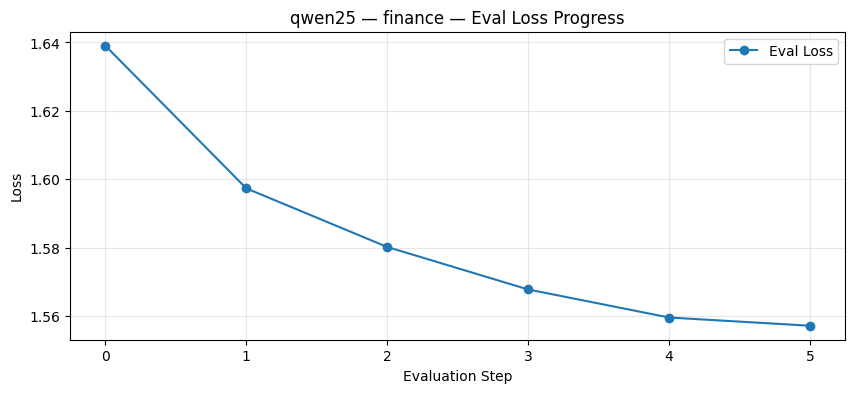


qwen25 finance fine-tuning complete!
GPU utilization should have been continuous with minimal spikes.

Model saved for: 08_Geometric_Audit.ipynb


In [13]:
# Display results
print(f"\n{'='*60}")
print(f"  TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Dataset: {finance_result['dataset']}")
print(f"Model: {finance_result['model']}")
print(f"Train Loss: {finance_result['train_loss']:.4f}")
print(f"Forgetting Signals: {len(finance_result.get('forgetting_signals', []))}")
print(f"GPU Issues: {len(finance_result.get('gpu_utilization_issues', []))}")
print(f"Model Path: {finance_result['model_path']}")

# Plot training progress
if finance_result.get('eval_losses'):
    plt.figure(figsize=(10, 4))
    plt.plot(finance_result['eval_losses'], 'o-', label='Eval Loss')
    plt.xlabel('Evaluation Step')
    plt.ylabel('Loss')
    plt.title(f'{MODEL_TAG} — {DATASET} — Eval Loss Progress')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print(f"\n{MODEL_TAG} {DATASET} fine-tuning complete!")
print("GPU utilization should have been continuous with minimal spikes.")
print("\nModel saved for: 08_Geometric_Audit.ipynb")

In [14]:
# Clean up
del model
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("GPU memory cleared.")

GPU memory cleared.
